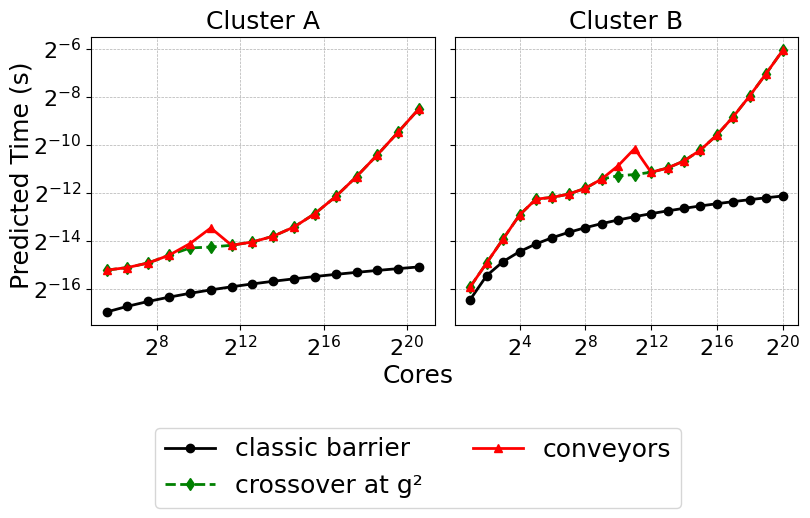

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Arrays — two different p arrays for each subplot
p1 = 24 * 2 ** np.arange(1, 17)
p2 = 2 ** np.arange(1, 21)

g = 24  # Fixed g

# Machine parameters for Cluster A
lambda_a = 8.9e-12
tau_a = 1.0e-6
mu_a = 3.9e-12

# Machine parameters for Cluster B
lambda_b = 4.17e-12
tau_b = 8e-6
mu_b = 1.6e-12

# Conveyor models
def conveyor_piecewise(p, g, _lambda, _tau, _mu):
    result = np.zeros_like(p, dtype=float)
    mask1 = p <= g
    result[mask1] = p[mask1] * (_tau + _mu)
    mask2 = (p > g) & (p <= g ** 2.5)
    result[mask2] = g * (_tau + _mu) + (p[mask2] / g) * (_tau + _lambda)
    mask3 = p > g ** 2.5
    result[mask3] = 2 * g * (_tau + _mu) + (p[mask3] / g ** 2) * (_tau + _lambda)
    return result

def conveyor_piecewise1(p, g, _lambda, _tau, _mu):
    result = np.zeros_like(p, dtype=float)
    mask1 = p <= g
    result[mask1] = p[mask1] * (_tau + _mu)
    mask2 = (p > g) & (p <= g ** 2)
    result[mask2] = g * (_tau + _mu) + (p[mask2] / g) * (_tau + _lambda)
    mask3 = p > g ** 2
    result[mask3] = 2 * g * (_tau + _mu) + (p[mask3] / g ** 2) * (_tau + _lambda)
    return result

def simple_barrier(p, _lambda, _tau, _mu):
    return 2 * (_tau + _lambda + _mu) * np.log(p)

# Compute values
conveyor1 = conveyor_piecewise(p1, g, lambda_a, tau_a, mu_a)
cross1 = conveyor_piecewise1(p1, g, lambda_a, tau_a, mu_a)
barrier1 = simple_barrier(p1, lambda_a, tau_a, mu_a)

conveyor2 = conveyor_piecewise(p2, g, lambda_b, tau_b, mu_b)
cross2 = conveyor_piecewise1(p2, g, lambda_b, tau_b, mu_b)
barrier2 = simple_barrier(p2, lambda_b, tau_b, mu_b)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

# Define common font sizes
label_fontsize = 18
tick_fontsize = 16
legend_fontsize = 18
title_fontsize = 18

# Cluster A
ax1.plot(p1, barrier1, marker='o', color='black', label='classic barrier', linewidth=2)
ax1.plot(p1, cross1, '--', marker='d', label='srossover at g²', color='green', linewidth=2)
ax1.plot(p1, conveyor1, marker='^', label='conveyors', color='red', linewidth=2)
ax1.set_title('Cluster A', fontsize=title_fontsize)
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.set_xscale('log', base=2)
ax1.set_yscale('log', base=2)
ax1.tick_params(axis='both', labelsize=tick_fontsize)

# Cluster B
ax2.plot(p2, barrier2, marker='o', color='black', label='classic barrier', linewidth=2)
ax2.plot(p2, cross2, '--', marker='d', label='crossover at g²', color='green', linewidth=2)
ax2.plot(p2, conveyor2, marker='^', label='conveyors', color='red', linewidth=2)
ax2.set_title('Cluster B', fontsize=title_fontsize)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.set_xscale('log', base=2)
ax2.set_yscale('log', base=2)
ax2.tick_params(axis='both', labelsize=tick_fontsize)

# Shared axis labels
fig.text(0.5, -0.02, 'Cores', ha='center', fontsize=label_fontsize)
fig.text(-0.01, 0.5, 'Predicted Time (s)', va='center', rotation='vertical', fontsize=label_fontsize)

# Shared legend
handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, frameon=True, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=legend_fontsize)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the legend
plt.savefig("theory-termination.png", dpi=600)
